# Exploratory Analysis

Seasonal patterns, long term trends, and variable relationships across 45 years of ERA5 reanalysis data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
bcolor = "darkslategrey"

month_lbls = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

df = pd.read_csv("../data/processed/mendoza_basin_monthly.csv", parse_dates=["time"], index_col="time")

print(f"Loaded {len(df)} months ({df.index[0].strftime('%Y-%m')} to {df.index[-1].strftime('%Y-%m')})")
print(f"Variables: {list(df.columns)}")
df.head()

Loaded 540 months (1980-01 to 2024-12)
Variables: ['precip_mm', 'temp_c', 'pev_mm', 'runoff_mm', 'soil_moisture_0_7cm']


,precip_mm,temp_c,pev_mm,runoff_mm,soil_moisture_0_7cm
time,,,,,
1980-01-01,63.820649,15.302368,183.912286,98.165597,0.191278
1980-02-01,93.886005,13.928650,148.222182,36.150087,0.191747
1980-03-01,66.787061,14.917786,132.601721,29.331790,0.162673
1980-04-01,162.947316,6.125000,59.435077,35.352784,0.201941
1980-05-01,115.186830,3.713196,39.293950,28.664771,0.218384


## Seasonal Climatology

I average the monthly values across all 45 years. This is to show the basin's normal water cycle. When it rains, when evaporation is at its peak, and when water stress occurs.


Mean annual precipitation:   806mm
Mean annual PET:             1247mm
Annual water deficit:       -441mm

Monthly Climate Extremes
Wettest Month: Jun
Driest Month:  Apr
Coldest Month: Jan
Warmest Month: Jul


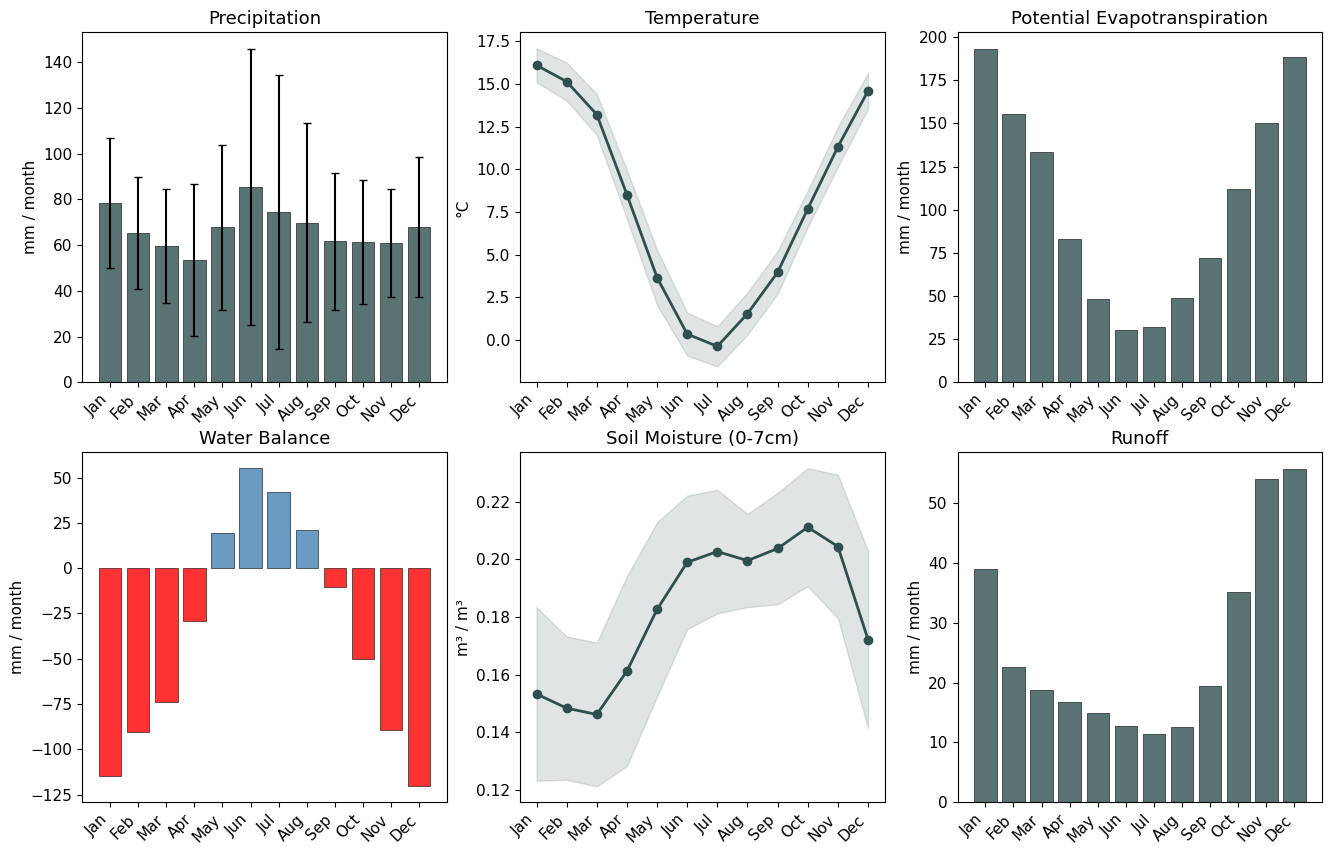

In [2]:
monthly_clim = df.groupby(df.index.month).agg(["mean", "std"])

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
months = range(1, 13)

# Precipitation
ax = axes[0, 0]
means = monthly_clim["precip_mm"]["mean"]
stds = monthly_clim["precip_mm"]["std"]
ax.bar(months, means, yerr=stds, color=bcolor, alpha=0.8, capsize=3, edgecolor="black", linewidth=0.5)
ax.set_ylabel("mm / month")
ax.set_title("Precipitation")
ax.set_xticks(months)
ax.set_xticklabels(month_lbls, rotation=45, ha="right")

# Temperature
ax = axes[0, 1]
means = monthly_clim["temp_c"]["mean"]
stds = monthly_clim["temp_c"]["std"]
ax.plot(months, means, "o-", color=bcolor, linewidth=2)
ax.fill_between(months, means - stds, means + stds, color=bcolor, alpha=0.15)
ax.set_ylabel("°C")
ax.set_title("Temperature")
ax.set_xticks(months)
ax.set_xticklabels(month_lbls, rotation=45, ha="right")

# PET
ax = axes[0, 2]
means = monthly_clim["pev_mm"]["mean"]
ax.bar(months, means, color=bcolor, alpha=0.8, edgecolor="black", linewidth=0.5)
ax.set_ylabel("mm / month")
ax.set_title("Potential Evapotranspiration")
ax.set_xticks(months)
ax.set_xticklabels(month_lbls, rotation=45, ha="right")

# Water Balance
ax = axes[1, 0]
p_means = monthly_clim["precip_mm"]["mean"]
pet_means = monthly_clim["pev_mm"]["mean"]
deficit = p_means.values - pet_means.values 
colors = ["steelblue" if d >= 0 else "red" for d in deficit]
ax.bar(months, deficit, color=colors, alpha=0.8, edgecolor="black", linewidth=0.5)
ax.set_ylabel("mm / month")
ax.set_title("Water Balance")
ax.set_xticks(months)
ax.set_xticklabels(month_lbls, rotation=45, ha="right")

# Soil Moisture
ax = axes[1, 1]
means = monthly_clim["soil_moisture_0_7cm"]["mean"]
stds = monthly_clim["soil_moisture_0_7cm"]["std"]
ax.plot(months, means, "o-", color=bcolor, linewidth=2)
ax.fill_between(months, means - stds, means + stds, color=bcolor, alpha=0.15)
ax.set_ylabel("m³ / m³")
ax.set_title("Soil Moisture (0-7cm)")
ax.set_xticks(months)
ax.set_xticklabels(month_lbls, rotation=45, ha="right")

# Runoff
ax = axes[1, 2]
means = monthly_clim["runoff_mm"]["mean"]
ax.bar(months, means, color=bcolor, alpha=0.8, edgecolor="black", linewidth=0.5)
ax.set_ylabel("mm / month")
ax.set_title("Runoff")
ax.set_xticks(months)
ax.set_xticklabels(month_lbls, rotation=45, ha="right")

# Overall Statistics
annual_precip = monthly_clim["precip_mm"]["mean"].sum()
annual_pet = monthly_clim["pev_mm"]["mean"].sum()
print(f"\nMean annual precipitation:   {annual_precip:.0f}mm")
print(f"Mean annual PET:             {annual_pet:.0f}mm")
print(f"Annual water deficit:       {annual_precip - annual_pet:.0f}mm")
print(f"\nMonthly Climate Extremes")
print(f"Wettest Month: {month_lbls[monthly_clim["precip_mm"]["mean"].idxmax()-1]}")
print(f"Driest Month:  {month_lbls[monthly_clim["precip_mm"]["mean"].idxmin()-1]}")
print(f"Coldest Month: {month_lbls[monthly_clim["temp_c"]["mean"].idxmax()-1]}")
print(f"Warmest Month: {month_lbls[monthly_clim["temp_c"]["mean"].idxmin()-1]}")

## Long Term Trends

Annual aggregations with linear trend lines. A positive temperature trend combined with declining precipitation would indicate increasing water stress.

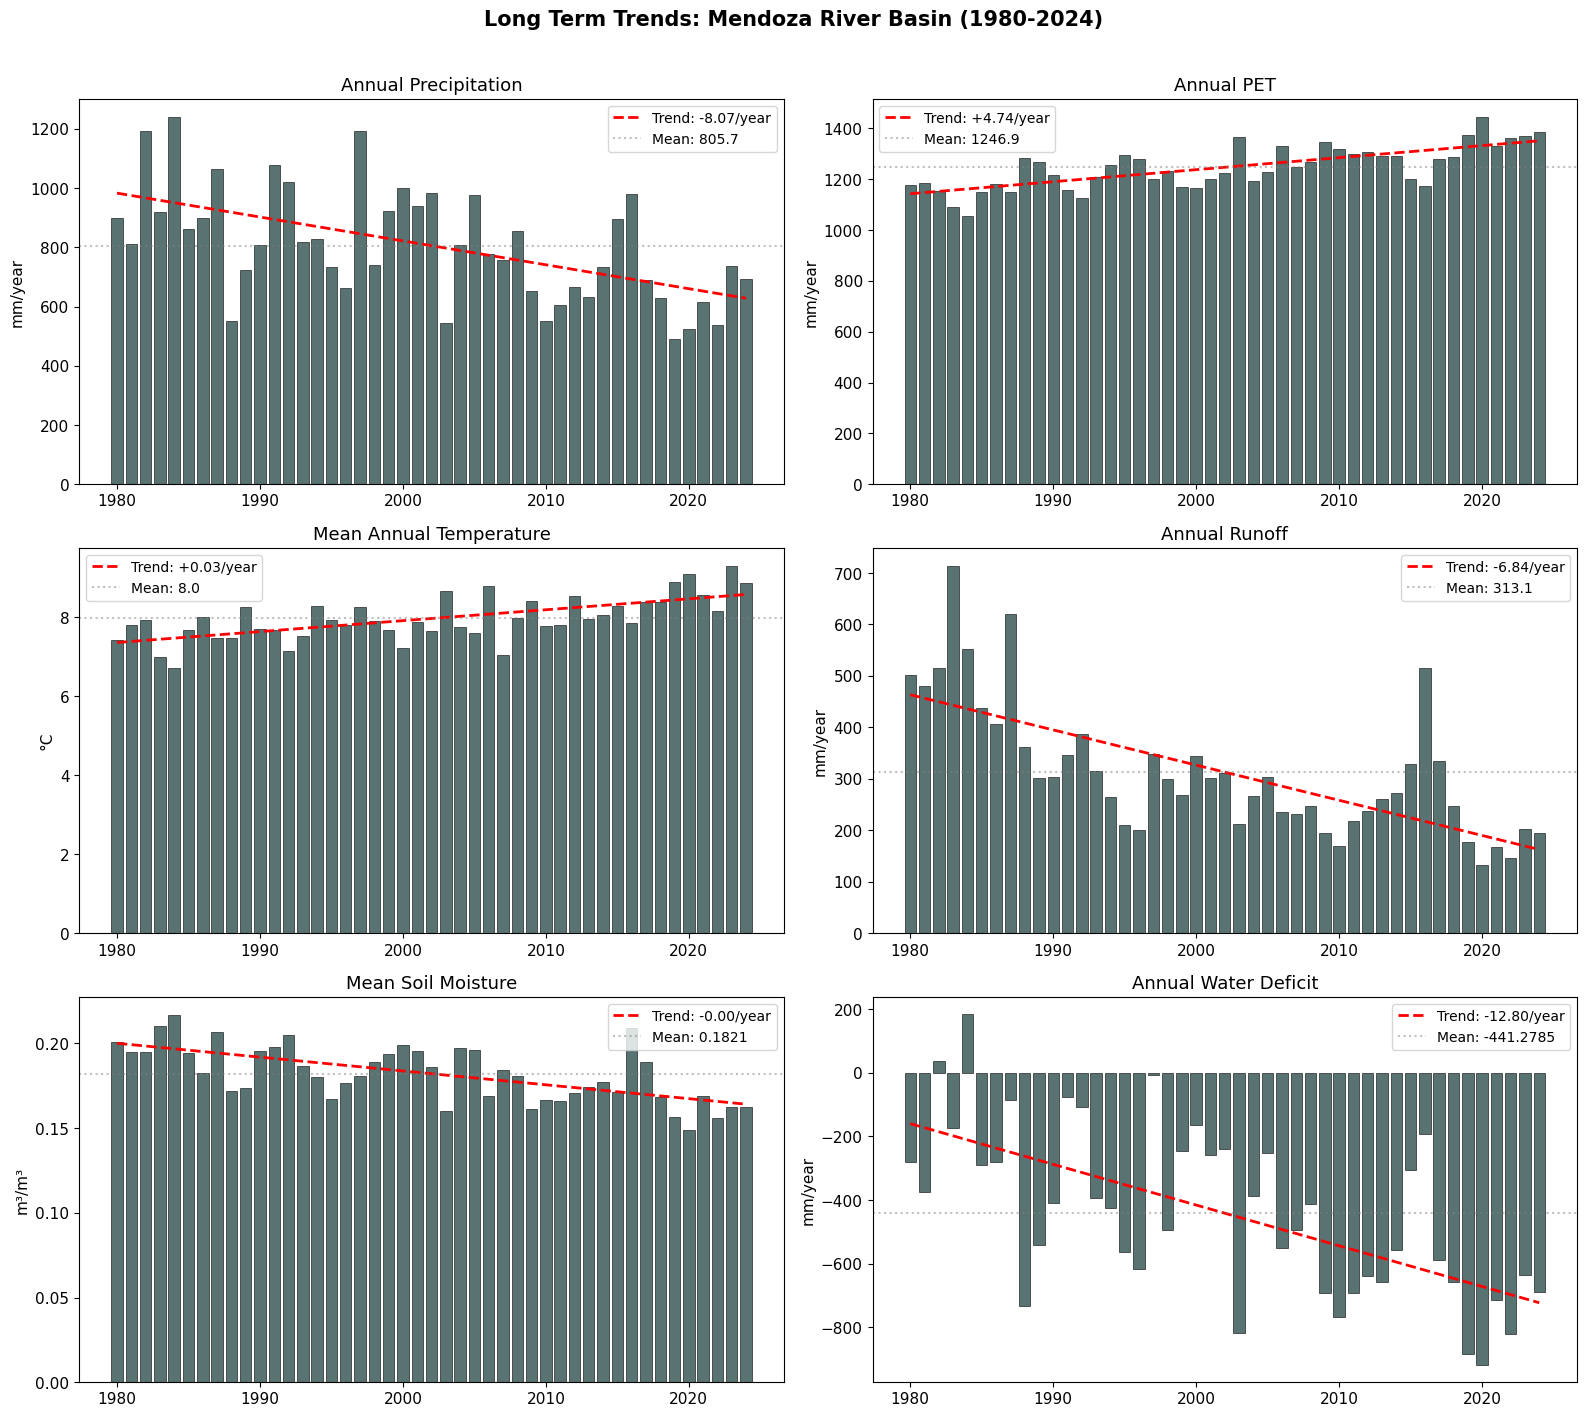

Precipitation       : -8.067/year -> -363.03 over 45 years
PET                 : +4.735/year -> +213.09 over 45 years
Temperature         : +0.028/year -> +1.24 over 45 years
Runoff              : -6.836/year -> -307.60 over 45 years
Soil Moisture       : -0.001/year -> -0.04 over 45 years


In [ ]:
annual = df.resample("YE").agg({
    "precip_mm": "sum",
    "pev_mm": "sum",
    "temp_c": "mean",
    "runoff_mm": "sum",
    "soil_moisture_0_7cm": "mean",
})
annual_index = annual.index.year

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# Used to create a trend bargraph with a smooth linear trend curve
def plot_trend(ax, years, values, ylabel, title, colour):
    ax.bar(years, values, color=colour, alpha=0.8, edgecolor="black", linewidth=0.5)

    z = np.polyfit(years, values, 1)
    trend = np.polyval(z, years)


    if abs(z[0]) < 0.01:
        label = f"Trend: {z[0]:+.5f}/year"
    else:
        label = f"Trend: {z[0]:+.2f}/year"

    ax.plot(years, trend, "r--", linewidth=2, label=f"Trend: {z[0]:+.2f}/year")

    ax.axhline(y=values.mean(), color="grey", linestyle=":", alpha=0.5, label=f"Mean: {values.mean():.4f}" if values.mean() < 1 else f"Mean: {values.mean():.1f}")

    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=10)

years = annual.index.year.values.astype(float)

plot_trend(axes[0,0], years, annual["precip_mm"].values, "mm/year", "Annual Precipitation", bcolor)
plot_trend(axes[0,1], years, annual["pev_mm"].values, "mm/year", "Annual PET", bcolor)
plot_trend(axes[1,0], years, annual["temp_c"].values, "°C", "Mean Annual Temperature", bcolor)
plot_trend(axes[1,1], years, annual["runoff_mm"].values, "mm/year", "Annual Runoff", bcolor)
plot_trend(axes[2,0], years, annual["soil_moisture_0_7cm"].values, "m³/m³", "Mean Soil Moisture", bcolor)

annual["deficit"] = annual["precip_mm"] - annual["pev_mm"] 
plot_trend(axes[2,1], years, annual["deficit"].values, "mm/year", "Annual Water Deficit", bcolor)

fig.suptitle("Long Term Trends: Mendoza River Basin (1980-2024)", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../outputs/figures/longterm_trends.png", dpi=150, bbox_inches="tight")
plt.show()

for var, label in [("precip_mm", "Precipitation"),
                   ("pev_mm", "PET"),
                   ("temp_c", "Temperature"),
                   ("runoff_mm", "Runoff"),
                   ("soil_moisture_0_7cm", "Soil Moisture")]:
    z = np.polyfit(years, annual[var].values, 1)
    total_change = z[0] * 45
    print(f"{label:20s}: {z[0]:+.3f}/year -> {total_change:+.2f} over 45 years")

## Variable Correlations

How the basin's variables relate to each other. Strong correlations reveal physical drivers (temperature drives PET) and inform feature selection for ML modelling.

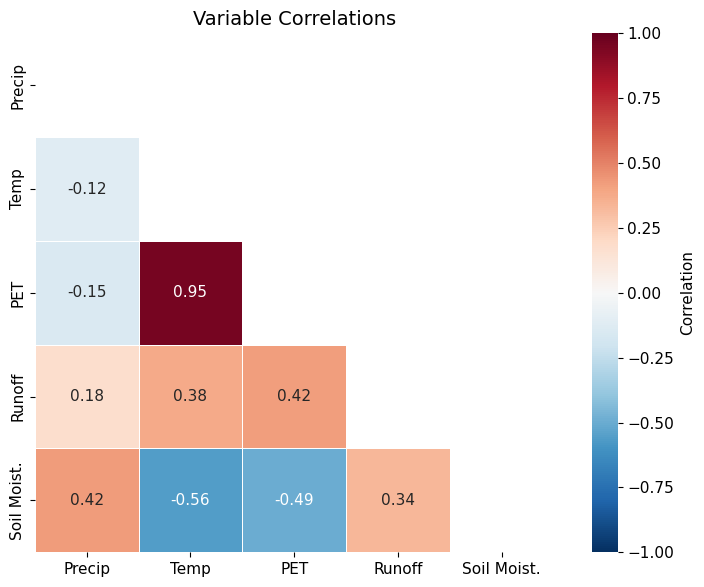

Correlations:
    Temp         | PET         : +0.953 (positive)
    Temp         | Soil Moist. : -0.561 (negative)
    PET          | Soil Moist. : -0.494 (negative)
    Precip       | Soil Moist. : +0.424 (positive)
    PET          | Runoff      : +0.419 (positive)
    Temp         | Runoff      : +0.382 (positive)
    Runoff       | Soil Moist. : +0.336 (positive)
    Precip       | Runoff      : +0.177 (positive)
    Precip       | PET         : -0.155 (negative)
    Precip       | Temp        : -0.123 (negative)


In [10]:
corr = df.corr()

label_map = {
    "precip_mm": "Precip",
    "temp_c": "Temp",
    "pev_mm": "PET",
    "runoff_mm": "Runoff",
    "soil_moisture_0_7cm": "Soil Moist.",
}

corr_display = corr.rename(index=label_map, columns=label_map)

fig, ax = plt.subplots(figsize=(8, 6))

mask = np.triu(np.ones_like(corr_display, dtype=bool))

sns.heatmap(corr_display, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax, cbar_kws={"label": "Correlation"})

ax.set_title("Variable Correlations", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/figures/correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("Correlations:")
pairs = []
for i, c1 in enumerate(df.columns):
    for c2 in df.columns[i+1:]:
        pairs.append((c1, c2, corr.loc[c1, c2]))

pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for c1, c2, r in pairs:
    direction = "positive" if r > 0 else "negative"
    print(f"    {label_map[c1]:12s} | {label_map[c2]:12s}: {r:+.3f} ({direction})")

## Precipitation Heatmap

Every month of precipitation visualised on a year × month grid. Horizontal bands of light colour indicate dry years (potential drought periods).

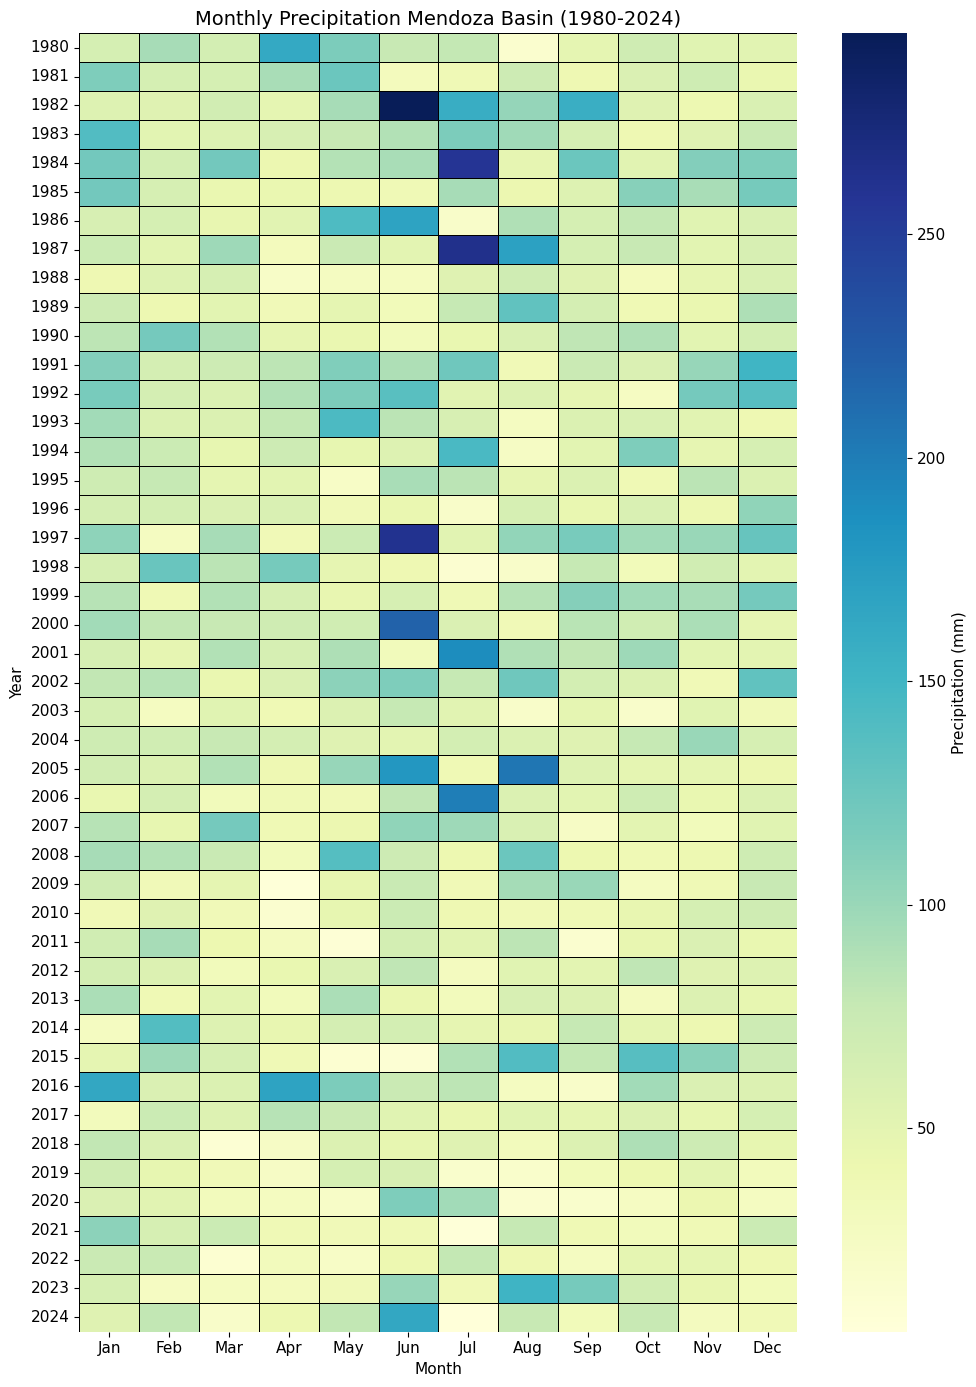

In [13]:
pivot_df = pd.DataFrame({
    "year" : df.index.year,
    "month" : df.index.month,
    "precip" : df["precip_mm"].values,
})
heatmap_data = pivot_df.pivot(index="year", columns="month", values="precip")
heatmap_data.columns = month_lbls

fig, ax = plt.subplots(figsize=(10, 14))
sns.heatmap(heatmap_data, cmap="YlGnBu", ax=ax, linewidths=0.5, linecolor="black", cbar_kws={"label" : "Precipitation (mm)"})
ax.set_title("Monthly Precipitation Mendoza Basin (1980-2024)", fontsize=14)
ax.set_ylabel("Year")
ax.set_xlabel("Month")
plt.tight_layout()
plt.savefig("../outputs/figures/precip_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Summary

Summary of the findings in the exploratory analysis

In [27]:
annual_p = df.resample("YE")["precip_mm"].sum()
annual_pet = df.resample("YE")["pev_mm"].sum()

years_float = np.arange(len(annual_p), dtype=float)
p_trend = np.polyfit(years_float, annual_p.values, 1)[0]
t_trend = np.polyfit(years_float, df.resample("YE")["temp_c"].mean().values, 1)[0]

print("         Mendoza River Basin Summary")
print("\nClimatology:")
print(f"    Mean Annual Precipitation:  {annual_p.mean():.0f}mm")
print(f"    Mean Annual PET:            {annual_pet.mean():.0f}mm")
print(f"    Mean Annual Water Deficit: {(annual_p - annual_pet).mean():.0f}mm")
print(f"    Wettest Month:  {month_lbls[monthly_clim["precip_mm"]["mean"].idxmax()-1]}")
print(f"    Driest Month:   {month_lbls[monthly_clim["precip_mm"]["mean"].idxmin()-1]}")

print("\nTrends (1980-2024):")
print(f"    Precipitation:  {p_trend:+.1f}mm/year")
print(f"    Temperature:    {t_trend:+.3f}°C/year")

print("\nDriest Years:")
driest = annual_p.sort_values().head(5)
for year, val in driest.items():
    print(f"    {year.year}: {val:.0f}mm")

print("\nWettest Years:")
wettest = annual_p.sort_values().tail(5)
for year, val in wettest.items():
    print(f"    {year.year}: {val:.0f}mm")

print("\nCorrelations:")
for c1, c2, r in pairs[:3]:
    print(f"    {label_map[c1]:12s} | {label_map[c2]:12s}: {r:+.3f}")

         Mendoza River Basin Summary

Climatology:
    Mean Annual Precipitation:  806mm
    Mean Annual PET:            1247mm
    Mean Annual Water Deficit: -441mm
    Wettest Month:  Jun
    Driest Month:   Apr

Trends (1980-2024):
    Precipitation:  -8.1mm/year
    Temperature:    +0.028°C/year

Driest Years:
    2019: 492mm
    2020: 526mm
    2022: 539mm
    2003: 545mm
    2010: 550mm

Wettest Years:
    1987: 1066mm
    1991: 1079mm
    1982: 1193mm
    1997: 1194mm
    1984: 1240mm

Correlations:
    Temp         | PET         : +0.953
    Temp         | Soil Moist. : -0.561
    PET          | Soil Moist. : -0.494
